In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── BASELINE STATS PER PAIR ──────────────────────────────
# Update these as your sample grows
BASELINES = {
    "XAUUSD": {
        "wr"    : 0.625,
        "exp"   : 1.91,
        "avg_w" : 2.46,
        "avg_l" : -1.00,
        "label" : "Gold"
    },
    "XAGUSD": {
        "wr"    : 0.50,   # placeholder — update after 25 trades
        "exp"   : 1.00,
        "avg_w" : 2.00,
        "avg_l" : -1.00,
        "label" : "Silver"
    },
    "NAS100": {
        "wr"    : 0.50,   # placeholder — update after 25 trades
        "exp"   : 1.00,
        "avg_w" : 2.00,
        "avg_l" : -1.00,
        "label" : "Nasdaq 100"
    },
    "GBPUSD": {
        "wr"    : 0.50,   # placeholder
        "exp"   : 1.00,
        "avg_w" : 2.00,
        "avg_l" : -1.00,
        "label" : "Cable"
    },
    "GBPJPY": {
        "wr"    : 0.50,   # placeholder
        "exp"   : 1.00,
        "avg_w" : 2.00,
        "avg_l" : -1.00,
        "label" : "The Beast"
    },
}

# ── GLOBAL SETTINGS ──────────────────────────────────────
RISK_PER_TRADE  = 100   # $100 at 1% of $10k
ACCOUNT         = 10000

# ── ALERT THRESHOLDS ─────────────────────────────────────
ALERT_WR        = 0.45  # below this = reduce size
ALERT_EXP       = 1.00  # below this = stop trading pair
ALERT_STREAK    = 3     # 3 consecutive losses = warning
ALERT_MONTHLY_R = 10.0  # below this monthly = review

# ── SETUPS ───────────────────────────────────────────────
SETUPS = ["SMC", "Lipschutz", "Powell", "Combined"]

print("Live Trade Tracker — Multi-Pair")
print("=" * 50)
print(f"Pairs tracked   : {list(BASELINES.keys())}")
print(f"Setups tracked  : {SETUPS}")
print(f"Risk per trade  : ${RISK_PER_TRADE}")
print(f"Account size    : ${ACCOUNT:,}")
print(f"\nAlert thresholds:")
print(f"  WR below      : {ALERT_WR:.0%}")
print(f"  Exp below     : +{ALERT_EXP:.2f}R")
print(f"  Loss streak   : {ALERT_STREAK}+ consecutive")
print(f"  Monthly R     : below +{ALERT_MONTHLY_R:.0f}R")

Live Trade Tracker — Multi-Pair
Pairs tracked   : ['XAUUSD', 'XAGUSD', 'NAS100', 'GBPUSD', 'GBPJPY']
Setups tracked  : ['SMC', 'Lipschutz', 'Powell', 'Combined']
Risk per trade  : $100
Account size    : $10,000

Alert thresholds:
  WR below      : 45%
  Exp below     : +1.00R
  Loss streak   : 3+ consecutive
  Monthly R     : below +10R


In [3]:
def add_trade(df, date, pair, direction, entry, sl, tp,
              exit_price, outcome, session, setup,
              notes=""):
    """
    Add a trade to the live tracker.
    pair     : XAUUSD, XAGUSD, NAS100, GBPUSD, GBPJPY
    direction: LONG or SHORT
    outcome  : WIN, LOSS, or BE
    session  : London, NY, Tokyo, Sydney, Overlap
    setup    : SMC, Lipschutz, Powell, Combined
    """
    risk_pips   = abs(entry - sl)
    reward_pips = abs(tp - entry)
    rr_ratio    = reward_pips / risk_pips \
                  if risk_pips > 0 else 0

    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk_pips
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk_pips
    else:
        actual_r = 0.0

    pnl_usd = actual_r * RISK_PER_TRADE

    new_trade = pd.DataFrame([{
        "date"      : pd.to_datetime(date),
        "pair"      : pair,
        "direction" : direction,
        "entry"     : entry,
        "sl"        : sl,
        "tp"        : tp,
        "exit_price": exit_price,
        "outcome"   : outcome,
        "session"   : session,
        "setup"     : setup,
        "notes"     : notes,
        "risk_pips" : round(risk_pips, 2),
        "rr_ratio"  : round(rr_ratio, 2),
        "actual_r"  : round(float(actual_r), 3),
        "pnl_usd"   : round(float(pnl_usd), 2)
    }])

    df = pd.concat([df, new_trade], ignore_index=True)
    print(f"  ✓ {date} | {pair} {direction} "
          f"{outcome} {actual_r:+.2f}R "
          f"(${pnl_usd:+.2f})")
    return df

# Initialise empty journal
journal = pd.DataFrame(columns=[
    'date','pair','direction','entry','sl','tp',
    'exit_price','outcome','session','setup','notes',
    'risk_pips','rr_ratio','actual_r','pnl_usd'
])

# ── LOAD YOUR EXISTING 16 XAUUSD TRADES ──────────────────
print("Loading existing XAU/USD trades...")
journal = add_trade(journal,"2026-07-02","XAUUSD","LONG",  4073.17,4046.97,4131.70,4182.47,"WIN", "Tokyo",  "SMC","")
journal = add_trade(journal,"2026-07-01","XAUUSD","SHORT", 4013.02,4035.51,3960.54,3960.54,"WIN", "NY",     "SMC","")
journal = add_trade(journal,"2026-06-29","XAUUSD","SHORT", 4031.33,4074.75,3972.48,3972.48,"WIN", "London", "SMC","")
journal = add_trade(journal,"2026-06-26","XAUUSD","LONG",  4090.06,4045.21,4147.94,4045.21,"LOSS","NY",     "SMC","")
journal = add_trade(journal,"2026-06-26","XAUUSD","SHORT", 4004.19,4028.52,3938.55,4028.52,"LOSS","Tokyo",  "SMC","")
journal = add_trade(journal,"2026-06-24","XAUUSD","SHORT", 4055.45,4085.88,3978.71,3978.71,"WIN", "London", "SMC","")
journal = add_trade(journal,"2026-06-23","XAUUSD","SHORT", 4104.02,4132.50,4033.45,4018.09,"WIN", "NY",     "SMC","")
journal = add_trade(journal,"2026-06-23","XAUUSD","SHORT", 4160.98,4216.54,4087.90,4087.90,"WIN", "Tokyo",  "SMC","")
journal = add_trade(journal,"2026-06-18","XAUUSD","SHORT", 4266.46,4316.42,4171.98,4171.98,"WIN", "London", "SMC","")
journal = add_trade(journal,"2026-06-16","XAUUSD","LONG",  4346.56,4316.71,4409.61,4316.71,"LOSS","London", "SMC","")
journal = add_trade(journal,"2026-06-15","XAUUSD","LONG",  4285.53,4207.56,4400.49,4207.56,"LOSS","Sydney", "SMC","")
journal = add_trade(journal,"2026-06-10","XAUUSD","SHORT", 4146.80,4198.67,4047.17,4047.17,"WIN", "London", "SMC","")
journal = add_trade(journal,"2026-06-09","XAUUSD","SHORT", 4300.25,4353.60,4220.56,4220.56,"WIN", "NY",     "SMC","")
journal = add_trade(journal,"2026-06-09","XAUUSD","SHORT", 4326.41,4353.60,4258.56,4353.60,"LOSS","London", "SMC","")
journal = add_trade(journal,"2026-06-05","XAUUSD","SHORT", 4461.43,4490.10,4396.79,4330.70,"WIN", "Sydney", "SMC","")
journal = add_trade(journal,"2026-06-03","XAUUSD","SHORT", 4438.73,4465.61,4368.90,4465.61,"LOSS","NY",     "SMC","")

print(f"\nJournal loaded: {len(journal)} trades")

Loading existing XAU/USD trades...
  ✓ 2026-07-02 | XAUUSD LONG WIN +4.17R ($+417.18)
  ✓ 2026-07-01 | XAUUSD SHORT WIN +2.33R ($+233.35)
  ✓ 2026-06-29 | XAUUSD SHORT WIN +1.36R ($+135.54)
  ✓ 2026-06-26 | XAUUSD LONG LOSS -1.00R ($-100.00)
  ✓ 2026-06-26 | XAUUSD SHORT LOSS -1.00R ($-100.00)
  ✓ 2026-06-24 | XAUUSD SHORT WIN +2.52R ($+252.19)
  ✓ 2026-06-23 | XAUUSD SHORT WIN +3.02R ($+301.72)
  ✓ 2026-06-23 | XAUUSD SHORT WIN +1.32R ($+131.53)
  ✓ 2026-06-18 | XAUUSD SHORT WIN +1.89R ($+189.11)
  ✓ 2026-06-16 | XAUUSD LONG LOSS -1.00R ($-100.00)
  ✓ 2026-06-15 | XAUUSD LONG LOSS -1.00R ($-100.00)
  ✓ 2026-06-10 | XAUUSD SHORT WIN +1.92R ($+192.08)
  ✓ 2026-06-09 | XAUUSD SHORT WIN +1.49R ($+149.37)
  ✓ 2026-06-09 | XAUUSD SHORT LOSS -1.00R ($-100.00)
  ✓ 2026-06-05 | XAUUSD SHORT WIN +4.56R ($+455.98)
  ✓ 2026-06-03 | XAUUSD SHORT LOSS -1.00R ($-100.00)

Journal loaded: 16 trades


In [5]:
def analyse_journal(df, pair=None):
    """
    Full analysis with edge drift detection.
    pair: filter by specific pair or None for all
    """
    if pair:
        df = df[df['pair']==pair].copy()
    if len(df) == 0:
        return None

    df = df.sort_values('date').reset_index(drop=True)

    # Force datetime conversion
    df['date'] = pd.to_datetime(df['date'])

    total  = len(df)
    wins   = (df['outcome']=='WIN').sum()
    losses = (df['outcome']=='LOSS').sum()
    be     = (df['outcome']=='BE').sum()
    wr     = wins / total
    avg_w  = df[df['outcome']=='WIN']['actual_r'].mean()
    avg_l  = df[df['outcome']=='LOSS']['actual_r'].mean()
    exp    = (wr * avg_w) + ((1-wr) * avg_l) \
             if not pd.isna(avg_l) else wr * avg_w
    tot_r  = df['actual_r'].sum()
    tot_usd= df['pnl_usd'].sum()

    # Rolling 10-trade stats
    recent     = df.tail(10)
    recent_wr  = (recent['outcome']=='WIN').mean()
    recent_exp = recent['actual_r'].mean()

    # Streak detection
    streak      = 0
    streak_type = None
    for _, row in df.iloc[::-1].iterrows():
        if streak == 0:
            streak_type = row['outcome']
            streak      = 1
        elif row['outcome'] == streak_type:
            streak += 1
        else:
            break

    # Monthly breakdown
    df['month'] = df['date'].dt.strftime('%Y-%m')
    monthly = df.groupby('month').agg(
        trades  = ('actual_r', 'count'),
        total_r = ('actual_r', 'sum'),
        wr      = ('outcome',
                   lambda x: (x=='WIN').mean())
    ).round(3)

    return {
        'total'      : total,
        'wins'       : wins,
        'losses'     : losses,
        'be'         : be,
        'wr'         : wr,
        'avg_w'      : avg_w,
        'avg_l'      : avg_l,
        'exp'        : exp,
        'tot_r'      : tot_r,
        'tot_usd'    : tot_usd,
        'recent_wr'  : recent_wr,
        'recent_exp' : recent_exp,
        'streak'     : streak,
        'streak_type': streak_type,
        'monthly'    : monthly,
        'df'         : df
    }

def check_alerts(stats, pair, baseline):
    alerts = []
    if stats['recent_wr'] < ALERT_WR:
        alerts.append(
            f"⚠️  WR ALERT: Last 10 trades WR "
            f"{stats['recent_wr']:.0%} "
            f"< {ALERT_WR:.0%} threshold")
    if stats['recent_exp'] < ALERT_EXP:
        alerts.append(
            f"⚠️  EXP ALERT: Last 10 trades exp "
            f"{stats['recent_exp']:+.2f}R "
            f"< +{ALERT_EXP:.2f}R threshold")
    if stats['streak_type'] == 'LOSS' and \
       stats['streak'] >= ALERT_STREAK:
        alerts.append(
            f"🛑 STREAK ALERT: {stats['streak']} "
            f"consecutive losses — reduce size to 0.5%")
    wr_drift  = stats['wr']  - baseline['wr']
    exp_drift = stats['exp'] - baseline['exp']
    if wr_drift < -0.15:
        alerts.append(
            f"📉 DRIFT ALERT: WR drifted "
            f"{wr_drift:+.0%} from baseline")
    if exp_drift < -0.75:
        alerts.append(
            f"📉 DRIFT ALERT: Expectancy drifted "
            f"{exp_drift:+.2f}R from baseline")
    return alerts

def print_report(pair=None):
    label = pair if pair else "ALL PAIRS"
    stats = analyse_journal(journal, pair)
    if stats is None:
        print(f"No trades for {label}")
        return

    baseline = BASELINES.get(pair, {
        "wr": 0.5, "exp": 1.0,
        "avg_w": 2.0, "avg_l": -1.0
    })

    print(f"\n{'='*58}")
    print(f"  LIVE TRACKER — {label}")
    print(f"{'='*58}")
    print(f"  Total trades     : {stats['total']}")
    print(f"  Wins/Losses/BE   : "
          f"{stats['wins']}/{stats['losses']}/{stats['be']}")
    print(f"  Win rate         : {stats['wr']:.1%}  "
          f"(baseline: {baseline['wr']:.1%})")
    print(f"  Avg win          : +{stats['avg_w']:.2f}R  "
          f"(baseline: +{baseline['avg_w']:.2f}R)")
    print(f"  Avg loss         : {stats['avg_l']:.2f}R")
    print(f"  Expectancy       : {stats['exp']:+.3f}R  "
          f"(baseline: +{baseline['exp']:.2f}R)")
    print(f"  Total R          : {stats['tot_r']:+.2f}R")
    print(f"  Total P&L        : ${stats['tot_usd']:+,.2f}")
    print(f"{'='*58}")
    print(f"  ROLLING (last 10 trades):")
    print(f"  Win rate         : {stats['recent_wr']:.1%}")
    print(f"  Expectancy       : {stats['recent_exp']:+.2f}R")
    print(f"{'='*58}")
    print(f"  STREAK: {stats['streak']} consecutive "
          f"{stats['streak_type']}S")
    print(f"{'='*58}")

    print(f"\n  MONTHLY BREAKDOWN:")
    print(f"  {'-'*45}")
    for month, row in stats['monthly'].iterrows():
        bar = '█' * max(0, int(abs(row['total_r'])))
        sign = '+' if row['total_r'] >= 0 else ''
        print(f"  {month}  n:{int(row['trades']):>3}  "
              f"WR:{row['wr']:>5.0%}  "
              f"R:{sign}{row['total_r']:>5.1f}  {bar}")

    alerts = check_alerts(stats, pair, baseline)
    if alerts:
        print(f"\n  ALERTS:")
        for a in alerts:
            print(f"  {a}")
    else:
        print(f"\n  ✅ All metrics within normal range")

# Run reports
print_report()
print_report("XAUUSD")


  LIVE TRACKER — ALL PAIRS
  Total trades     : 16
  Wins/Losses/BE   : 10/6/0
  Win rate         : 62.5%  (baseline: 50.0%)
  Avg win          : +2.46R  (baseline: +2.00R)
  Avg loss         : -1.00R
  Expectancy       : +1.161R  (baseline: +1.00R)
  Total R          : +18.58R
  Total P&L        : $+1,858.05
  ROLLING (last 10 trades):
  Win rate         : 70.0%
  Expectancy       : +1.36R
  STREAK: 3 consecutive WINS

  MONTHLY BREAKDOWN:
  ---------------------------------------------
  2026-06  n: 14  WR:  57%  R:+ 12.1  ████████████
  2026-07  n:  2  WR: 100%  R:+  6.5  ██████

  ✅ All metrics within normal range

  LIVE TRACKER — XAUUSD
  Total trades     : 16
  Wins/Losses/BE   : 10/6/0
  Win rate         : 62.5%  (baseline: 62.5%)
  Avg win          : +2.46R  (baseline: +2.46R)
  Avg loss         : -1.00R
  Expectancy       : +1.161R  (baseline: +1.91R)
  Total R          : +18.58R
  Total P&L        : $+1,858.05
  ROLLING (last 10 trades):
  Win rate         : 70.0%
  Expecta

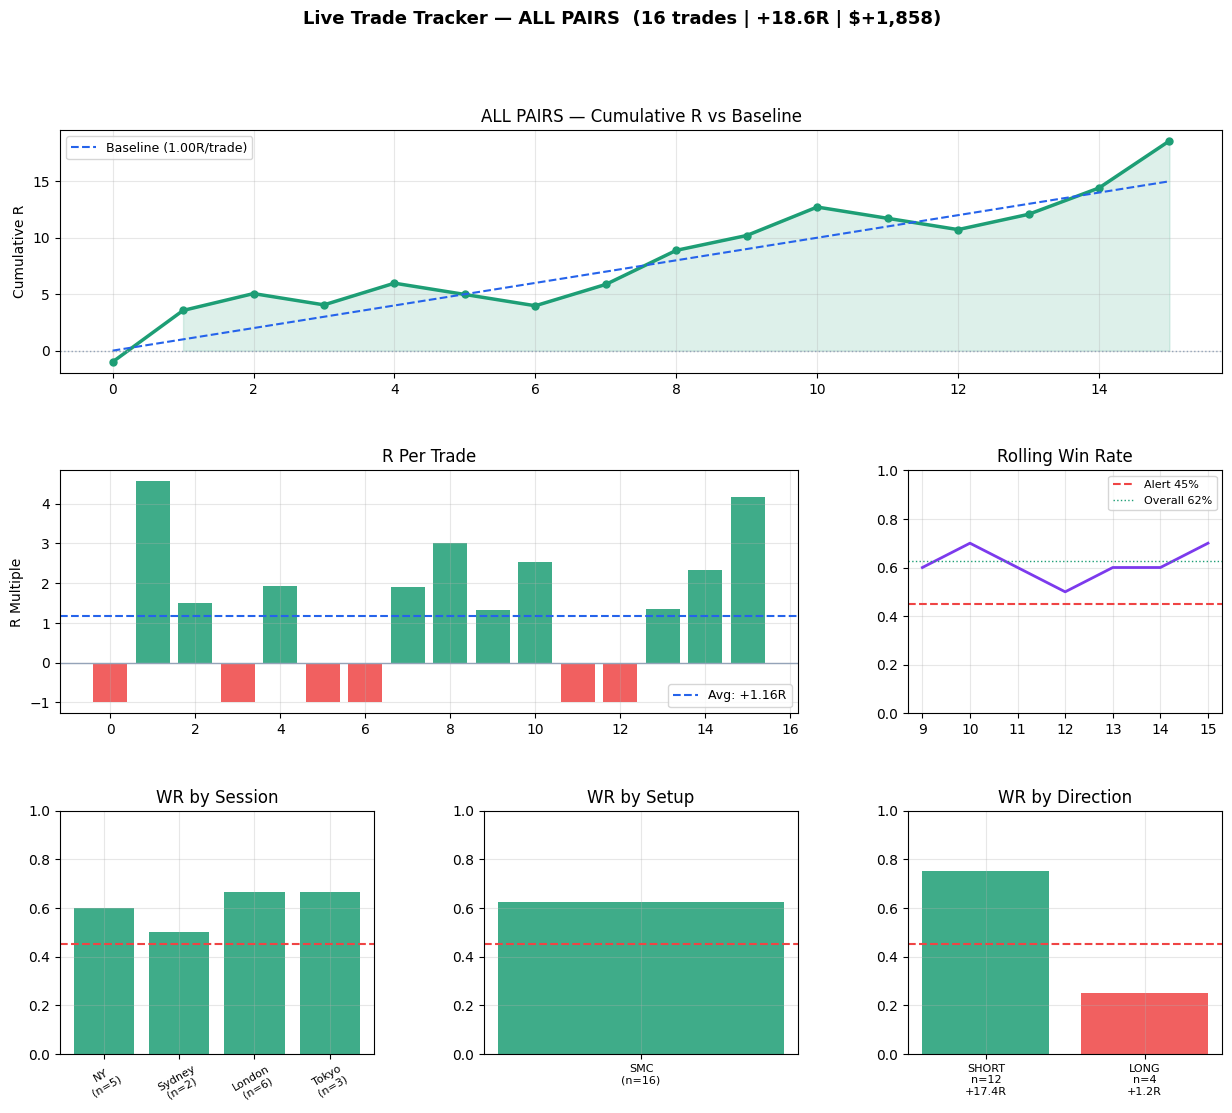

Dashboard saved to tracker_ALL_PAIRS.png


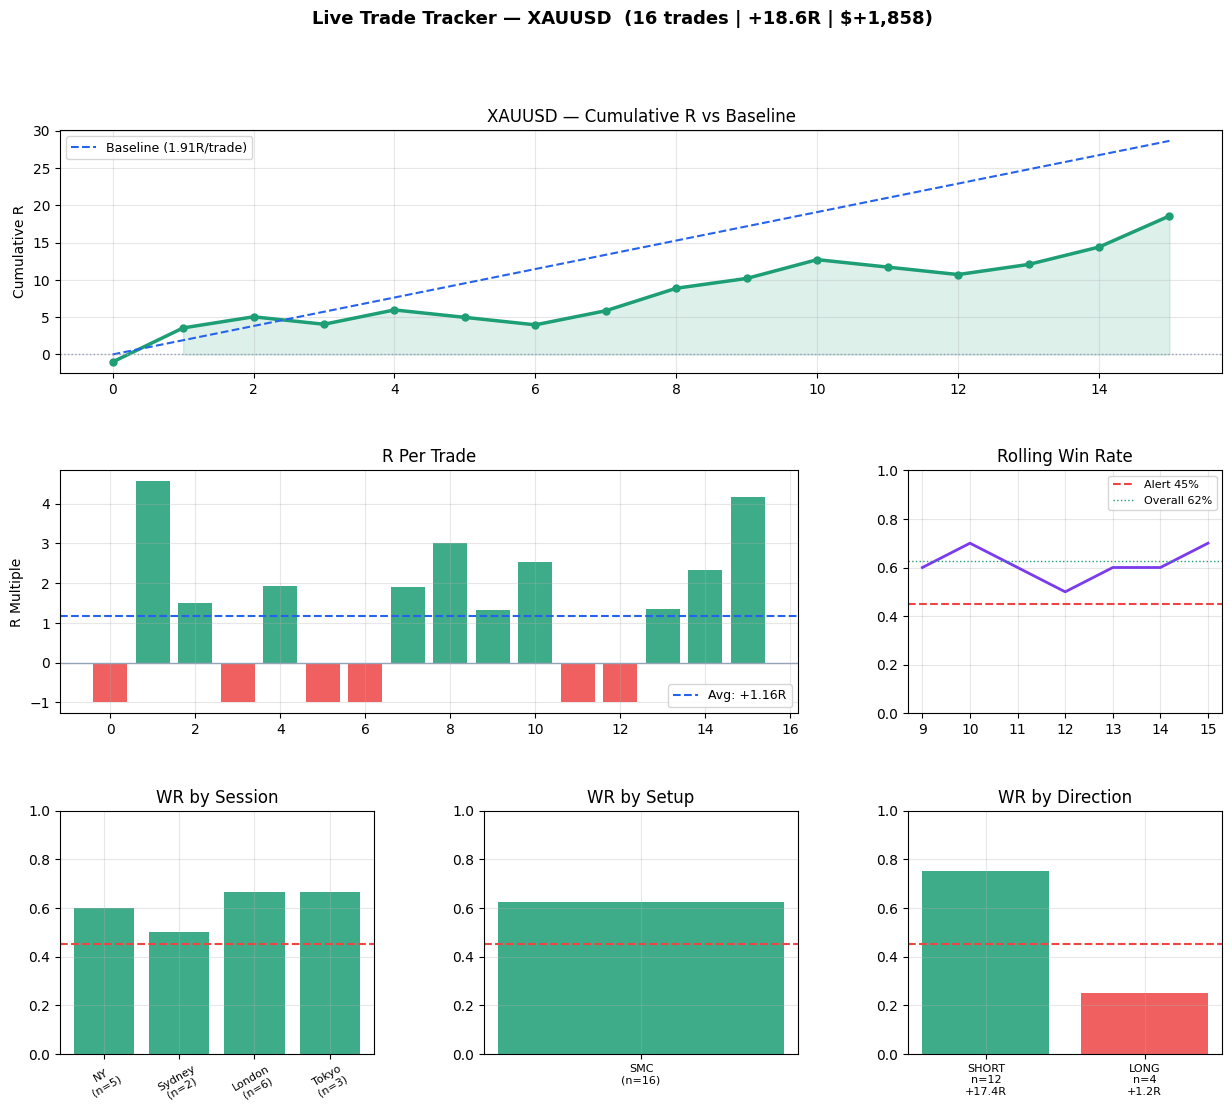

Dashboard saved to tracker_XAUUSD.png


In [7]:
def plot_dashboard(pair=None):
    """Full visual dashboard for live tracking."""
    label = pair if pair else "ALL PAIRS"
    stats = analyse_journal(journal, pair)
    if stats is None:
        print(f"No trades for {label}")
        return

    df    = stats['df']
    df['cumulative_r'] = df['actual_r'].astype(float).cumsum()

    fig = plt.figure(figsize=(15, 12))
    gs  = gridspec.GridSpec(3, 3, figure=fig,
                             hspace=0.4, wspace=0.35)

    # ── Panel 1: Cumulative R curve ──────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    x   = np.arange(len(df), dtype=float)
    cum = df['cumulative_r'].astype(float).values
    ax1.plot(x, cum, color='#1D9E75', lw=2.5,
             marker='o', markersize=5)
    ax1.fill_between(x, cum, 0,
                     where=(cum>=0),
                     alpha=0.15, color='#1D9E75')
    ax1.fill_between(x, cum, 0,
                     where=(cum<0),
                     alpha=0.15, color='#ef4444')

    # Baseline expectancy line
    baseline_exp = BASELINES.get(pair,
                  {"exp":1.0})['exp'] if pair else 1.0
    ax1.plot(x, baseline_exp * x,
             color='#2563eb', lw=1.5,
             linestyle='--',
             label=f'Baseline ({baseline_exp:.2f}R/trade)')
    ax1.axhline(0, color='#94a3b8', lw=1,
                linestyle=':')
    ax1.set_title(f'{label} — Cumulative R vs Baseline',
                  fontsize=12)
    ax1.set_ylabel('Cumulative R')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # ── Panel 2: R per trade ─────────────────────────────
    ax2  = fig.add_subplot(gs[1, :2])
    act  = df['actual_r'].astype(float).values
    cols = ['#1D9E75' if r > 0 else '#ef4444'
            for r in act]
    ax2.bar(x, act, color=cols, alpha=0.85)
    ax2.axhline(0, color='#94a3b8', lw=1)
    ax2.axhline(act.mean(), color='#2563eb',
                lw=1.5, linestyle='--',
                label=f'Avg: {act.mean():+.2f}R')
    ax2.set_title('R Per Trade')
    ax2.set_ylabel('R Multiple')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # ── Panel 3: Rolling 10-trade WR ─────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    if len(df) >= 5:
        roll_wr = df['actual_r'].astype(float).apply(
            lambda x: 1 if x > 0 else 0
        ).rolling(min(10, len(df))).mean()
        ax3.plot(range(len(roll_wr)),
                 roll_wr.values,
                 color='#7c3aed', lw=2)
        ax3.axhline(ALERT_WR, color='#ef4444',
                    lw=1.5, linestyle='--',
                    label=f'Alert {ALERT_WR:.0%}')
        ax3.axhline(stats['wr'], color='#1D9E75',
                    lw=1, linestyle=':',
                    label=f'Overall {stats["wr"]:.0%}')
        ax3.set_ylim(0, 1)
        ax3.set_title('Rolling Win Rate')
        ax3.legend(fontsize=8)
        ax3.grid(True, alpha=0.3)

    # ── Panel 4: WR by session ───────────────────────────
    ax4      = fig.add_subplot(gs[2, 0])
    sessions = df['session'].unique()
    sess_wr  = [(df[df['session']==s]['outcome']=='WIN').mean()
                for s in sessions]
    sess_n   = [len(df[df['session']==s]) for s in sessions]
    colors   = ['#1D9E75' if w >= ALERT_WR
                else '#ef4444' for w in sess_wr]
    ax4.bar(range(len(sessions)), sess_wr,
            color=colors, alpha=0.85)
    ax4.axhline(ALERT_WR, color='#ef4444',
                lw=1.5, linestyle='--')
    ax4.set_xticks(range(len(sessions)))
    ax4.set_xticklabels(
        [f"{s}\n(n={n})"
         for s, n in zip(sessions, sess_n)],
        fontsize=8, rotation=30)
    ax4.set_ylim(0, 1)
    ax4.set_title('WR by Session')
    ax4.grid(True, alpha=0.3)

    # ── Panel 5: WR by setup ─────────────────────────────
    ax5    = fig.add_subplot(gs[2, 1])
    setups = df['setup'].unique()
    s_wr   = [(df[df['setup']==s]['outcome']=='WIN').mean()
              for s in setups]
    s_n    = [len(df[df['setup']==s]) for s in setups]
    s_cols = ['#1D9E75' if w >= ALERT_WR
              else '#ef4444' for w in s_wr]
    ax5.bar(range(len(setups)), s_wr,
            color=s_cols, alpha=0.85)
    ax5.axhline(ALERT_WR, color='#ef4444',
                lw=1.5, linestyle='--')
    ax5.set_xticks(range(len(setups)))
    ax5.set_xticklabels(
        [f"{s}\n(n={n})"
         for s, n in zip(setups, s_n)],
        fontsize=8)
    ax5.set_ylim(0, 1)
    ax5.set_title('WR by Setup')
    ax5.grid(True, alpha=0.3)

    # ── Panel 6: Direction breakdown ─────────────────────
    ax6  = fig.add_subplot(gs[2, 2])
    dirs = df['direction'].unique()
    d_wr = [(df[df['direction']==d]['outcome']=='WIN').mean()
            for d in dirs]
    d_r  = [df[df['direction']==d]['actual_r'].sum()
            for d in dirs]
    d_n  = [len(df[df['direction']==d]) for d in dirs]
    d_cols = ['#1D9E75' if w >= ALERT_WR
              else '#ef4444' for w in d_wr]
    bars = ax6.bar(range(len(dirs)), d_wr,
                   color=d_cols, alpha=0.85)
    ax6.axhline(ALERT_WR, color='#ef4444',
                lw=1.5, linestyle='--')
    ax6.set_xticks(range(len(dirs)))
    ax6.set_xticklabels(
        [f"{d}\nn={n}\n{r:+.1f}R"
         for d, n, r in zip(dirs, d_n, d_r)],
        fontsize=8)
    ax6.set_ylim(0, 1)
    ax6.set_title('WR by Direction')
    ax6.grid(True, alpha=0.3)

    plt.suptitle(
        f"Live Trade Tracker — {label}  "
        f"({len(df)} trades | "
        f"{stats['tot_r']:+.1f}R | "
        f"${stats['tot_usd']:+,.0f})",
        fontsize=13, fontweight='bold')
    plt.savefig(f'tracker_{label.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Dashboard saved to "
          f"tracker_{label.replace(' ','_')}.png")

# Plot dashboard
plot_dashboard()
plot_dashboard("XAUUSD")

In [8]:
def dynamic_position_size(pair, account=ACCOUNT):
    """
    Kelly-based position sizer using LIVE stats.
    Updates automatically as you add more trades.
    """
    stats = analyse_journal(journal, pair)

    if stats is None or stats['total'] < 10:
        print(f"  {pair}: Need 10+ trades for Kelly "
              f"(have {stats['total'] if stats else 0})")
        # Use baseline while building sample
        baseline = BASELINES.get(pair, {
            "wr": 0.5, "exp": 1.0,
            "avg_w": 2.0, "avg_l": -1.0
        })
        wr    = baseline['wr']
        avg_w = baseline['avg_w']
        avg_l = abs(baseline['avg_l'])
        source = "BASELINE"
    else:
        wr     = stats['wr']
        avg_w  = stats['avg_w']
        avg_l  = abs(stats['avg_l'])
        source = "LIVE"

    # Kelly fraction
    kelly     = wr - ((1-wr) / (avg_w / avg_l))
    half_k    = kelly / 2
    safe_pct  = min(max(half_k, 0.005), 0.02)
    risk_usd  = account * safe_pct

    return {
        'pair'     : pair,
        'source'   : source,
        'wr'       : wr,
        'avg_w'    : avg_w,
        'kelly'    : kelly,
        'half_k'   : half_k,
        'safe_pct' : safe_pct,
        'risk_usd' : risk_usd
    }

print(f"{'='*62}")
print(f"  DYNAMIC POSITION SIZER — ${ACCOUNT:,} ACCOUNT")
print(f"{'='*62}")
print(f"  {'Pair':<10} {'Source':<10} {'WR':>6} "
      f"{'Kelly':>8} {'Safe%':>7} {'Risk$':>8}")
print(f"  {'-'*57}")

for pair in BASELINES.keys():
    ps = dynamic_position_size(pair)
    print(f"  {ps['pair']:<10} {ps['source']:<10} "
          f"{ps['wr']:>6.0%} "
          f"{ps['kelly']:>8.1%} "
          f"{ps['safe_pct']:>7.1%} "
          f"${ps['risk_usd']:>7.0f}")

print(f"{'='*62}")
print(f"\n  XAUUSD lot sizes at current risk level:")
print(f"  (using live stats)")
ps = dynamic_position_size("XAUUSD")
for stop in [15, 20, 26, 30, 40, 50]:
    lots = ps['risk_usd'] / (stop * 100)
    print(f"  Stop {stop:>3} pips → "
          f"{lots:.3f} lots "
          f"({lots*10:.2f} mini / "
          f"{lots*100:.1f} micro)")

  DYNAMIC POSITION SIZER — $10,000 ACCOUNT
  Pair       Source         WR    Kelly   Safe%    Risk$
  ---------------------------------------------------------
  XAUUSD     LIVE          62%    47.2%    2.0% $    200
  XAGUSD: Need 10+ trades for Kelly (have 0)
  XAGUSD     BASELINE      50%    25.0%    2.0% $    200
  NAS100: Need 10+ trades for Kelly (have 0)
  NAS100     BASELINE      50%    25.0%    2.0% $    200
  GBPUSD: Need 10+ trades for Kelly (have 0)
  GBPUSD     BASELINE      50%    25.0%    2.0% $    200
  GBPJPY: Need 10+ trades for Kelly (have 0)
  GBPJPY     BASELINE      50%    25.0%    2.0% $    200

  XAUUSD lot sizes at current risk level:
  (using live stats)
  Stop  15 pips → 0.133 lots (1.33 mini / 13.3 micro)
  Stop  20 pips → 0.100 lots (1.00 mini / 10.0 micro)
  Stop  26 pips → 0.077 lots (0.77 mini / 7.7 micro)
  Stop  30 pips → 0.067 lots (0.67 mini / 6.7 micro)
  Stop  40 pips → 0.050 lots (0.50 mini / 5.0 micro)
  Stop  50 pips → 0.040 lots (0.40 mini / 4.